In [ ]:
import os
import time
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.notebook import tqdm 

from sklearn.neighbors import NearestNeighbors

from torch.utils.tensorboard import SummaryWriter

import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

from models.oneD_unet_cond import Unet
from ddpm.OneD_ddpm import DDPM
from evaluation.evaluation_metrics import plot_kde_samples, calculate_stat_metrics, plot_metric, calc_acf, plot_acfs, make_gif_from_images, plot_knn_ts

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

In [ ]:
## Data
seq_len = 336
batch_size = 128

#NN
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = "cpu"
cond_model = "mlp"
lr = 1e-4
betas = (0.9, 0.99)
epochs = 5000
save_rate = 50

## DDPM
timesteps = 1000

## Logging
experiment = f"rq1_{seq_len}"
#experiment = "dev"
experiment_name = f"unet_cond_{epochs//1000}kepochs_{seq_len}seq_2"
logging_dir = f"logging/{experiment}/{experiment_name}/"

In [ ]:
if not os.path.isdir(logging_dir):
    os.makedirs(logging_dir)
    os.makedirs(os.path.join(logging_dir, "viz/"))
    os.makedirs(os.path.join(logging_dir, "metrics/"))
    os.makedirs(os.path.join(logging_dir, "kde/"))
    os.makedirs(os.path.join(logging_dir, "tensorboard/"))
    os.makedirs(os.path.join(logging_dir, "weights/"))
    os.makedirs(os.path.join(logging_dir, "time/"))
    os.makedirs(os.path.join(logging_dir, "knn/"))

# Utils

In [17]:
PREPROCESSED_DIR = "./preprocessing/data/customer_led_network_revolution/preprocessed/"

In [18]:
def time_fe(df, timestamps, seq_len):
    num_customer = df.shape[0]
    conditioning_data = np.zeros((num_customer, 4, seq_len)) #4 is the number of features you want to extract

    for i in range(num_customer):
        customer_start_date = timestamps[i]
        for j in range(seq_len):
            current_date = customer_start_date + pd.Timedelta(days=j)
            
            day = current_date.day
            hour = current_date.hour
            minute = current_date.minute
            is_weekend = int(day in([5, 6]))
            
            day_sin = np.sin(2 * np.pi * day / 7)
            hour_sin = np.sin(2 * np.pi * hour / 24)
            minute_sin = np.sin(2 * np.pi * minute / 60)
        
            conditioning_data[i, 0, j] = day_sin
            conditioning_data[i, 1, j] = hour_sin
            conditioning_data[i, 2, j] = minute_sin
            conditioning_data[i, 3, j] = is_weekend

    return conditioning_data

# Load Data

In [19]:
train = pd.read_csv(os.path.join(PREPROCESSED_DIR, "train.csv"), index_col="Location ID")
val = pd.read_csv(os.path.join(PREPROCESSED_DIR, "val.csv"), index_col="Location ID")
test = pd.read_csv(os.path.join(PREPROCESSED_DIR, "test.csv"), index_col="Location ID")

In [20]:
train_seq = train.iloc[:, :seq_len]
train_time = pd.to_datetime(train.columns, format='%d/%m/%Y %H:%M:%S')
train_con = time_fe(train_seq, train_time, seq_len)
train_seq = np.asarray(train_seq).reshape(train_seq.shape[0], 1, train_seq.shape[1])
train_seq.shape, train_con.shape

((3037, 1, 336), (3037, 4, 336))

In [21]:
val_seq = val.iloc[:, :seq_len]
val_time = pd.to_datetime(val.columns, format='%d/%m/%Y %H:%M:%S')
val_con = time_fe(val_seq, val_time, seq_len)
val_seq = np.asarray(val_seq).reshape(val_seq.shape[0], 1, val_seq.shape[1])
val_seq.shape, val_con.shape

((537, 1, 336), (537, 4, 336))

In [22]:
test_seq = test.iloc[:, :seq_len]
test_time = pd.to_datetime(test.columns, format='%d/%m/%Y %H:%M:%S')
test_con = time_fe(test_seq, test_time, seq_len)
test_seq = np.asarray(test_seq).reshape(test_seq.shape[0], 1, test_seq.shape[1])
test_seq.shape, test_con.shape

((894, 1, 336), (894, 4, 336))

In [23]:
train_dataset = TensorDataset(torch.from_numpy(train_seq), torch.from_numpy(train_con))
train_loader = DataLoader(train_dataset, batch_size, shuffle=False)

val_dataset = TensorDataset(torch.from_numpy(val_seq), torch.from_numpy(val_con))
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

test_dataset = TensorDataset(torch.from_numpy(test_seq), torch.from_numpy(test_con))
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

In [24]:
real_data_val, real_cond_data_val = next(iter(val_loader))

# Load model

In [25]:
model = Unet(
    in_channels=train_seq.shape[1],
    out_channels=train_seq.shape[1],
    time_embedding_dim=32,
    base_channels=32,
    channel_mults=(1, 2, 4),
    cond_in_channels=train_con.shape[1],
    cond_sequence_length=seq_len,
    cond_embedding_dim=32
)

ddpm = DDPM(
        model=model,
        timesteps=timesteps,
        device=device
    )

optim = Adam(model.parameters(), lr=lr)
writer = SummaryWriter(os.path.join(logging_dir, "tensorboard/"))

In [26]:
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(f"{params}\n11342417")

1278369
11342417


In [ ]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    
    for i, (data, cond_data) in enumerate(train_loader):
        data = data.to(device)
        data = data.float()
        cond_data = cond_data.float()
        cond_data = cond_data.to(device)
        
        optim.zero_grad()
        
        t = torch.randint(0, ddpm.timesteps, (data.shape[0],), device=device)
        
        loss = ddpm.p_losses(data, t, c=cond_data)
        loss.backward()
        
        optim.step()
        running_loss += loss.item()
        
        if i % 100 == 0:
            last_loss = running_loss / 1000 # loss per batch
            tb_x = epoch_index * len(train_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
    return last_loss

In [ ]:
start_time = time.time()

epoch_number = 0
best_val_loss = 1_000_000.
save_dir =  os.path.join(logging_dir, "weights/")

for epoch in tqdm(range(1, epochs+1)):
    print('epoch {}:'.format(epoch_number + 1))
    
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)
    
    running_val_loss = 0.0
    
    model.eval()
    with torch.no_grad():
        for i, (val_data, val_cond) in enumerate(val_loader):
            val_data = val_data.to(device)
            val_data = val_data.float()
        
            val_cond = val_cond.float()
            val_cond = val_cond.to(device)
            
            t = torch.randint(0, ddpm.timesteps, (val_data.shape[0],), device=device)
            
            val_loss = ddpm.p_losses(val_data, t, c=val_cond)
            
            running_val_loss += val_loss
    
    avg_val_loss = running_val_loss / (i + 1)
    print('Loss train {} val {}'.format(avg_loss, avg_val_loss))
    
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_val_loss },
                    epoch_number + 1)
    
    writer.flush()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch_number
        best_ddpm_model = ddpm.model.state_dict()
        best_optim_state_dict = optim.state_dict()
        
    
    if epoch_number % save_rate == 0:
        generated_sample = ddpm.sample(batch_size, seq_len=seq_len, features=val_data.shape[1])
        generated_sample = generated_sample.cpu().numpy()
        
        plot_kde_samples(generated_sample, real_data_val,show=False, fpath=os.path.join(logging_dir, "kde/", f"kde_epoch_{epoch_number}.png"), epoch=epoch_number)
        
        model_name = f"model_epoch_{epoch_number}_val_{avg_val_loss:.4f}.pth"
        torch.save({
            'epoch': epoch_number,
            'diffusion_state_dict': ddpm.model.state_dict(),
            'diffusion_optim_state_dict': optim.state_dict()},
            os.path.join(save_dir, model_name))
    
    epoch_number += 1

end_time = time.time()
elapsed_time = end_time - start_time
formatted_time = str(timedelta(seconds=int(elapsed_time)))

In [ ]:
out_path = os.path.join(logging_dir, "time/", "compute_time.txt")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w") as f:
    f.write(f"Time to train {epochs} epochs with batch size {batch_size} and sequece {seq_len}: {formatted_time}")

In [ ]:
model_name = f"best_model.pth"
torch.save({
    'epoch': best_epoch,
    'diffusion_state_dict': best_ddpm_model,
    'diffusion_optim_state_dict': best_optim_state_dict},
    os.path.join(logging_dir, "weights/", model_name))

In [29]:
ddpm.model.load_state_dict(torch.load(os.path.join(logging_dir, "weights/", "best_model.pth"))["diffusion_state_dict"])

C:\Users\Arne\AppData\Local\Temp\ipykernel_26828\1150675024.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ddpm.model.load_state_dict(torch.load(os.path.join(logging_di

<All keys matched successfully>

In [ ]:
paths = []
for kde_plot in os.listdir(os.path.join(logging_dir, "kde/")):
    paths.append(os.path.join(logging_dir, "kde/", kde_plot))

make_gif_from_images(paths, os.path.join(logging_dir, "kde/", "kde_progression.gif"))

# Evaluation

In [30]:
real_data_test, real_cond_data_test = next(iter(test_loader))

In [32]:
with torch.no_grad():
    samples = ddpm.sample(batch_size, seq_len=seq_len, features=real_data_test.shape[1], c=real_cond_data_test.float().to(device))
    samples = samples.cpu().numpy()

print(f"Samples shape: {samples.shape}")

Sampling loop: 100%|██████████| 1000/1000 [00:11<00:00, 84.68it/s]

Samples shape: (128, 1, 336)


## Basic Statistical Features

In [ ]:
plot_kde_samples(samples, real_data_test, fpath=os.path.join(logging_dir, "kde/", f"kde.png"))

In [ ]:
batch_idx = np.random.randint(0, 256) 
customer_indices = np.random.randint(0, 15, size=15)
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

with torch.no_grad():
    sample = ddpm.sample(batch_size, seq_len=seq_len, features=val_data.shape[1], c=real_cond_data_test.float().to(device)) 
    sample = sample.cpu().numpy() 

for i in customer_indices:
    axs[0].plot(sample[i, 0, :], alpha=0.7, label=f'Customer {i}')
    axs[1].plot(real_data_test[i, 0, :], alpha=0.7, label=f'Customer {i}')

axs[0].set_title("Generated Data")
axs[1].set_title("Real Data")

for ax in axs:
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(logging_dir, "viz/", "samples.png"))
plt.show()

In [ ]:
gen_mean, gen_sd, gen_kurt, gen_skew, gen_min, gen_max = calculate_stat_metrics(samples, batch_size)
real_mean, real_sd, real_kurt, real_skew, real_min, real_max = calculate_stat_metrics(real_data_test, batch_size)

In [ ]:
plot_metric(real_mean, gen_mean, "Mean", save_path=os.path.join(logging_dir, "metrics/", f"mean.png"))

In [ ]:
plot_metric(real_sd, gen_sd, "Standard Deviation", save_path=os.path.join(logging_dir, "metrics/", f"sd.png"))

In [ ]:
plot_metric(real_kurt, gen_kurt, "Kurtosis", save_path=os.path.join(logging_dir, "metrics/", f"kurt.png"))

In [ ]:
plot_metric(real_skew, gen_skew, "Skew", save_path=os.path.join(logging_dir, "metrics/", f"skew.png"))

In [ ]:
plot_metric(real_min, gen_min, "Min value", save_path=os.path.join(logging_dir, "metrics/", f"min.png"))

In [ ]:
plot_metric(real_max, gen_max, "Max value", save_path=os.path.join(logging_dir, "metrics/", f"max.png"))

## Temporal / Dynamic Features

In [ ]:
lags = [1, 2, 24, 48, 96, 335]

for lag in lags:
    real_acf = calc_acf(real_data_test, lag)
    gen_acf = calc_acf(samples, lag)
    
    plot_acfs(real_acf, gen_acf, lag, save_path=os.path.join(logging_dir, "metrics/", f"ACF_{lag}.png"))

In [35]:
# samples = np.random.rand(128, 1, 336)
# real_data = np.random.rand(128, 1, 336)

if samples.shape[1] == 1:
    samples_reshaped = samples.reshape(samples.shape[0], samples.shape[2])
else:
    samples_reshaped = samples.reshape(samples.shape[0], -1)
    
if real_data_test.shape[1] == 1:
    real_data_reshaped = real_data_test.reshape(real_data_test.shape[0], real_data_test.shape[2])
else:
    real_data_reshaped = real_data_test.reshape(real_data_test.shape[0], -1)

k_neighbors_to_find = 3
knn_model = NearestNeighbors(n_neighbors=k_neighbors_to_find, algorithm='auto', metric='euclidean')
knn_model.fit(real_data_reshaped)

distances, indices = knn_model.kneighbors(samples_reshaped)

num_series_to_show_results_for = 2
for i in range(min(num_series_to_show_results_for, samples_reshaped.shape[0])):
    print(f"\nTime series {i} from Generated data:")
    for j in range(k_neighbors_to_find):
        neighbor_idx = indices[i][j]
        dist = distances[i][j]
        print(f"  Neighbor {j+1}: Index {neighbor_idx} from real data (Distance: {dist:.4f})")



Time series 0 from Generated data:
  Neighbor 1: Index 114 from real data (Distance: 3.1162)
  Neighbor 2: Index 99 from real data (Distance: 3.3840)
  Neighbor 3: Index 98 from real data (Distance: 3.4225)

Time series 1 from Generated data:
  Neighbor 1: Index 114 from real data (Distance: 3.2658)
  Neighbor 2: Index 34 from real data (Distance: 3.3550)
  Neighbor 3: Index 115 from real data (Distance: 3.4052)


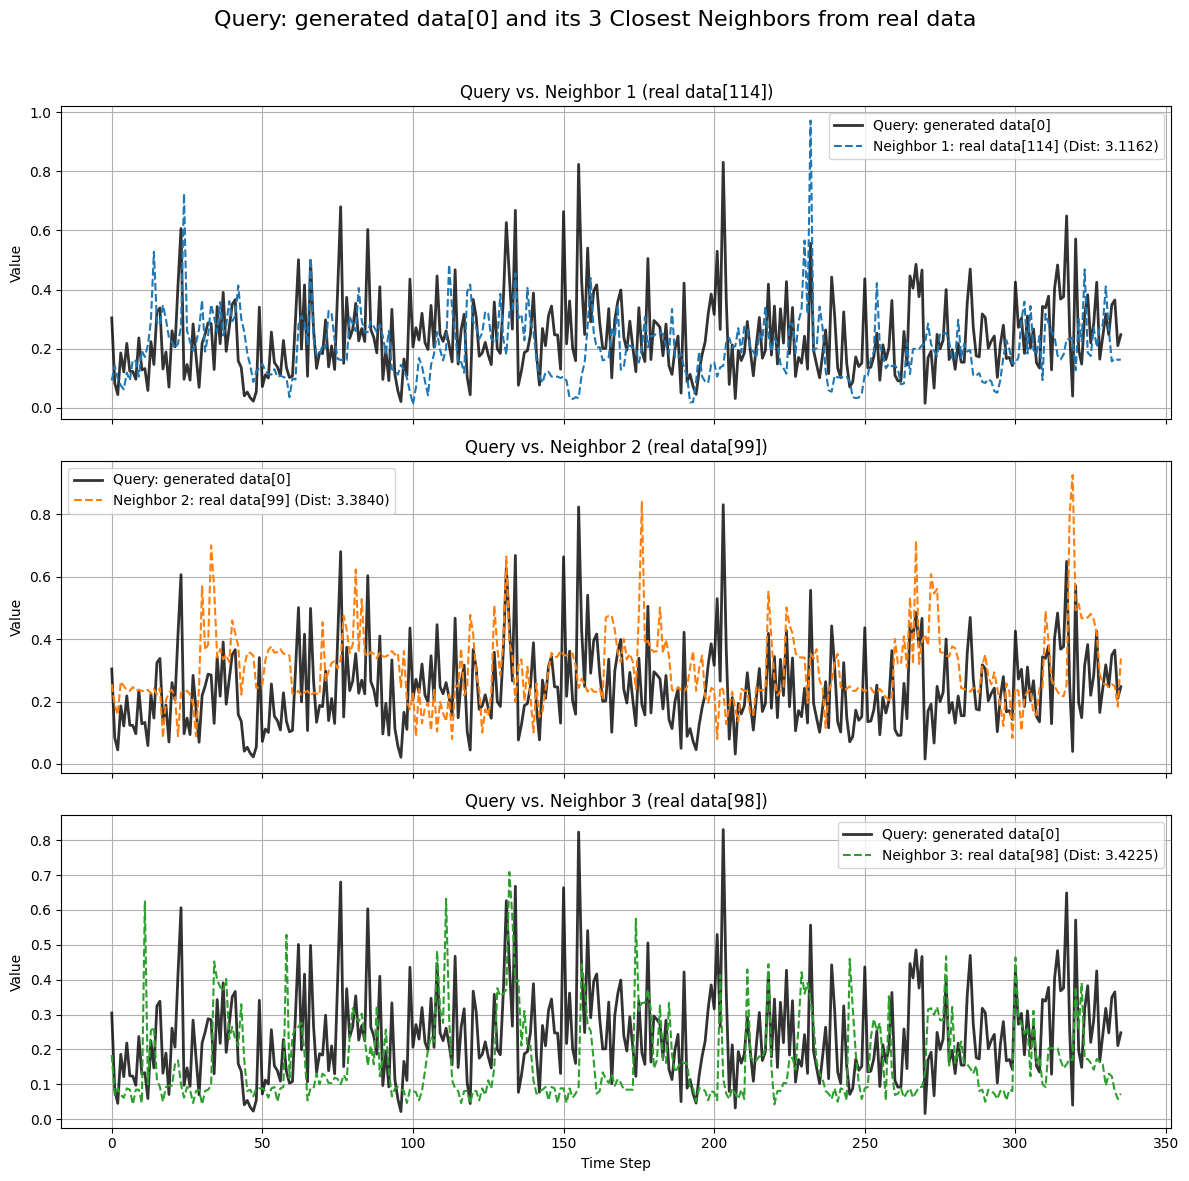

In [ ]:
query_index_to_plot = 0
plot_knn_ts(
    query_idx_in_sample1=query_index_to_plot,
    original_sample1=samples,
    original_sample2=real_data_test,
    neighbor_indices_in_sample2=indices[query_index_to_plot],
    k_neighbors=k_neighbors_to_find,
    neighbor_distances=distances[query_index_to_plot],
    save_path=os.path.join(logging_dir, "knn/", f"knn.png")
)